# Week 4 · Task 1 — Bootstrap confidence intervals, from scratch

**Roadmap task:** *Bootstrap confidence intervals from scratch. Check against `scipy`.*

Code: `mathkit/bootstrap.py`. Tests: `tests/test_bootstrap.py` (checked against `scipy.stats.bootstrap` and the classical t-interval).

**What this notebook shows**

1. Standard error — "how much would my number wobble if I collected the data again?" — measured the *impossible* way (re-collecting data from a known population) and the *bootstrap* way (resampling the one sample we have).
2. The bootstrap algorithm, and three ways to turn it into an interval.
3. A check against `scipy.stats.bootstrap` and against the textbook t-interval.
4. The real power: intervals for things with **no simple formula** (a median, a difference in medians, a correlation), on real data.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mathkit.bootstrap import bootstrap_distribution, bootstrap_ci, bootstrap_se

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(11)

## 1. Standard error — the impossible way first

**In simple words:** you never have the whole population, only a sample. Your sample mean is a *guess* at the population mean. If you went out and collected a fresh sample, you'd get a slightly different guess. The **standard error (SE)** is the standard deviation of those guesses.

To see it directly we'd need to collect the data again and again. We can only do that in a simulation, where *we* invent the population. Let's make a skewed "population" — delivery times in minutes, say — and a sample of $n = 40$.

In [2]:
population = rng.lognormal(mean=3.2, sigma=0.5, size=1_000_000)     # a skewed population we control
true_mean = population.mean()
n = 40
sample = rng.choice(population, n)                                  # the ONE sample we'd have in real life

# The impossible way: re-collect a fresh sample 20,000 times
recollected_means = rng.choice(population, (20_000, n)).mean(axis=1)
true_se = recollected_means.std()

print(f"true population mean      = {true_mean:.2f}")
print(f"our sample mean           = {sample.mean():.2f}")
print(f"TRUE standard error       = {true_se:.3f}   (from re-collecting 20,000 times - impossible in real life)")
print(f"formula  s / sqrt(n)      = {sample.std(ddof=1) / np.sqrt(n):.3f}   (uses only our one sample)")
print(f"bootstrap SE              = {bootstrap_se(sample, np.mean, rng=1):.3f}   (uses only our one sample)")

true population mean      = 27.80
our sample mean           = 25.46
TRUE standard error       = 2.347   (from re-collecting 20,000 times - impossible in real life)
formula  s / sqrt(n)      = 2.232   (uses only our one sample)
bootstrap SE              = 2.186   (uses only our one sample)


Both one-sample estimates land close to the true SE — without ever seeing the population. They're not exact (our sample's own spread is itself a noisy estimate of the population's spread), but they're in the right place. That's the whole game.

## 2. The bootstrap algorithm

**In simple words:** *pretend your sample is the population.* Then "collecting a new sample" becomes "drawing $n$ values from your sample, **with replacement**". Some values get picked twice, some not at all. Recompute your statistic. Repeat 10,000 times. The spread of those recomputed values estimates the wobble.

```python
idx = rng.integers(0, n, size=(n_boot, n))   # n_boot rows of n random positions (with replacement)
replicates = statistic(data[idx], axis=1)    # recompute the statistic on each row
```

That's the heart of `bootstrap_distribution` — two lines, fully vectorised.

**Why "with replacement"?** Without it, every resample would just be your sample shuffled, and the mean would be identical every time — zero wobble. Replacement is what creates sample-to-sample variation, mimicking the randomness of real data collection.

In [3]:
tiny = np.array([12, 15, 9, 30, 22])
print("original sample:", tiny, "  mean", tiny.mean())
r = np.random.default_rng(3)
for i in range(5):
    re = tiny[r.integers(0, len(tiny), len(tiny))]
    print(f"resample {i + 1}:      {re}   mean {re.mean():.1f}")

original sample: [12 15  9 30 22]   mean 17.6
resample 1:      [22 12 12 15 12]   mean 14.6
resample 2:      [22 22  9 12 12]   mean 15.4
resample 3:      [15  9 30  9 15]   mean 15.6
resample 4:      [12 30 30 12 12]   mean 19.2
resample 5:      [ 9 15 22  9  9]   mean 12.8


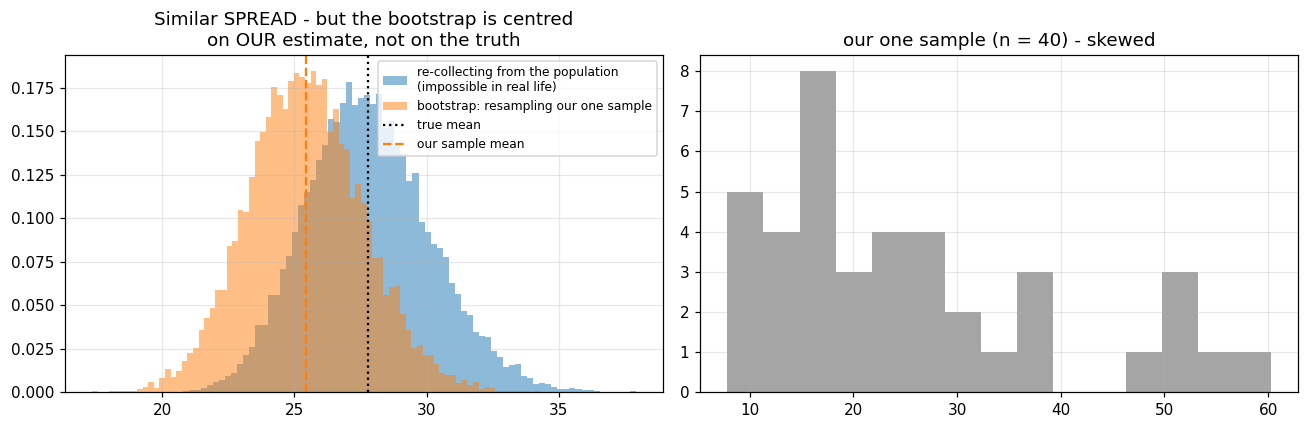

In [4]:
reps = bootstrap_distribution(sample, np.mean, n_boot=10_000, rng=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(recollected_means, bins=80, density=True, alpha=0.5, label="re-collecting from the population\n(impossible in real life)")
axes[0].hist(reps, bins=80, density=True, alpha=0.5, label="bootstrap: resampling our one sample")
axes[0].axvline(true_mean, color="k", ls=":", label="true mean")
axes[0].axvline(sample.mean(), color="tab:orange", ls="--", label="our sample mean")
axes[0].set_title("Similar SPREAD - but the bootstrap is centred\non OUR estimate, not on the truth"); axes[0].legend(fontsize=8)
axes[1].hist(sample, bins=15, alpha=0.7, color="tab:gray"); axes[1].set_title(f"our one sample (n = {n}) - skewed")
fig.tight_layout(); fig.savefig(FIG / "w4_bootstrap_vs_reality.png", dpi=150); plt.show()

**This is the key picture.** The bootstrap can't know where the truth is — it's centred on our estimate. What it *does* capture well is how wide the wobble is. That's exactly what we need for an interval.

## 3. From bootstrap replicates to a 95% interval

Let $\hat\theta$ be our estimate and $q_{2.5}, q_{97.5}$ the 2.5th and 97.5th percentiles of the bootstrap replicates.

| method | interval | idea |
|---|---|---|
| **percentile** | $[q_{2.5},\; q_{97.5}]$ | the middle 95% of the replicates — simplest |
| **basic** (reverse percentile) | $[2\hat\theta - q_{97.5},\; 2\hat\theta - q_{2.5}]$ | if replicates overshoot $\hat\theta$ by $d$, assume $\hat\theta$ overshoots the truth by $d$ too, and flip |
| **normal** | $\hat\theta \pm 1.96 \times \text{SE}_{\text{boot}}$ | assume a bell shape, use the bootstrap only for the SE |

## 4. Check against SciPy and the textbook formula

In [5]:
t_lo, t_hi = stats.t.interval(0.95, n - 1, loc=sample.mean(), scale=stats.sem(sample))
print(f"{'method':<34} {'lower':>8} {'upper':>8}")
print(f"{'t-interval (textbook formula)':<34} {t_lo:8.3f} {t_hi:8.3f}")
for method in ["percentile", "basic", "normal"]:
    lo, hi = bootstrap_ci(sample, np.mean, method=method, n_boot=50_000, rng=5)
    print(f"{'mathkit bootstrap - ' + method:<34} {lo:8.3f} {hi:8.3f}")
for method in ["percentile", "basic", "BCa"]:
    ci = stats.bootstrap((sample,), np.mean, method=method, n_resamples=50_000, random_state=5).confidence_interval
    print(f"{'scipy.stats.bootstrap - ' + method:<34} {ci.low:8.3f} {ci.high:8.3f}")

method                                lower    upper
t-interval (textbook formula)        20.944   29.974
mathkit bootstrap - percentile       21.344   29.943
mathkit bootstrap - basic            20.975   29.574
mathkit bootstrap - normal           21.136   29.782
scipy.stats.bootstrap - percentile   21.290   29.890
scipy.stats.bootstrap - basic        21.028   29.628
scipy.stats.bootstrap - BCa          21.572   30.294


Our percentile and basic intervals match SciPy's to within Monte-Carlo noise (different random resamples → last-digit differences; the unit tests check this with 20,000 resamples). SciPy's default, **BCa** ("bias-corrected and accelerated"), adjusts for skew and bias and is usually the most accurate — worth knowing the name for interviews; the percentile method is the one to understand first.

The t-interval and the bootstrap agree closely for the **mean** — because for means we have a formula. The bootstrap earns its place for everything else:

## 5. The real power — statistics with no easy formula, on real data

Back to the SMS dataset from Week 3. **Question: are spam messages longer than normal ones — and by how much, with what uncertainty?** Message lengths are skewed, so the *median* is a better summary than the mean. There's no simple textbook formula for the standard error of a *difference in medians*. The bootstrap doesn't care.

In [6]:
lines = (pathlib.Path.cwd().parent / "data" / "sms_spam.tsv").read_text(encoding="utf-8").splitlines()
lab = np.array([l.split("\t", 1)[0] for l in lines])
length = np.array([len(l.split("\t", 1)[1]) for l in lines])
spam_len, ham_len = length[lab == "spam"], length[lab == "ham"]

def diff_in_medians(n_boot=10_000, seed=0):
    r = np.random.default_rng(seed)
    s = spam_len[r.integers(0, len(spam_len), (n_boot, len(spam_len)))]    # resample EACH group separately
    h = ham_len[r.integers(0, len(ham_len), (n_boot, len(ham_len)))]
    return np.median(s, axis=1) - np.median(h, axis=1)

d_hat = np.median(spam_len) - np.median(ham_len)
d_reps = diff_in_medians()
lo, hi = np.quantile(d_reps, [0.025, 0.975])
print(f"median length: spam {np.median(spam_len):.0f} chars, ham {np.median(ham_len):.0f} chars")
print(f"difference in medians = {d_hat:.0f} characters,  95% bootstrap CI [{lo:.0f}, {hi:.0f}]")

median length: spam 149 chars, ham 52 chars
difference in medians = 97 characters,  95% bootstrap CI [94, 99]


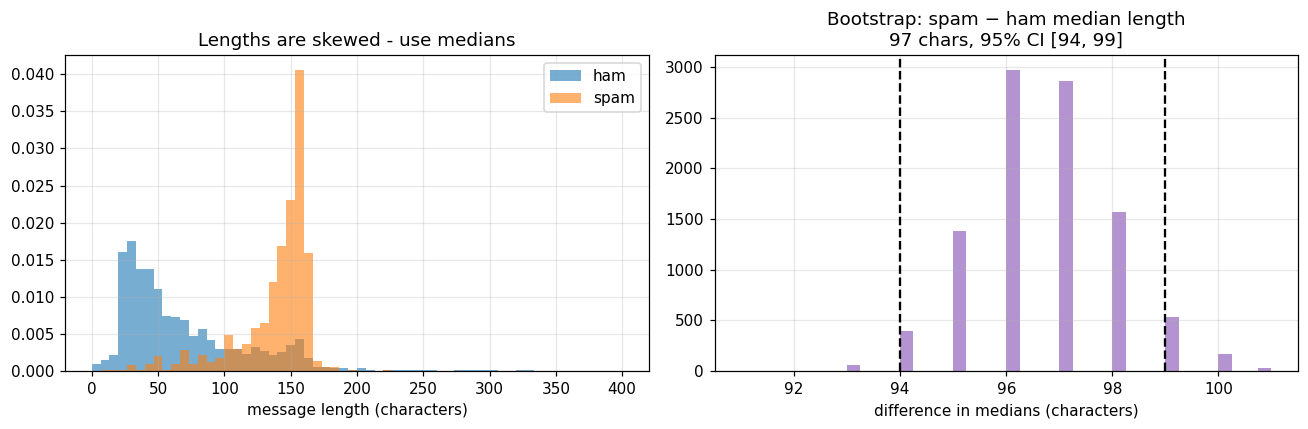

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ham_len, bins=60, range=(0, 400), alpha=0.6, density=True, label="ham")
axes[0].hist(spam_len, bins=60, range=(0, 400), alpha=0.6, density=True, label="spam")
axes[0].set_xlabel("message length (characters)"); axes[0].set_title("Lengths are skewed - use medians"); axes[0].legend()
axes[1].hist(d_reps, bins=40, alpha=0.7, color="tab:purple")
for v in (lo, hi):
    axes[1].axvline(v, color="k", ls="--")
axes[1].set_title(f"Bootstrap: spam − ham median length\n{d_hat:.0f} chars, 95% CI [{lo:.0f}, {hi:.0f}]")
axes[1].set_xlabel("difference in medians (characters)")
fig.tight_layout(); fig.savefig(FIG / "w4_sms_length_ci.png", dpi=150); plt.show()

**How to report it:** *"Spam messages are longer: the median spam message is about 97 characters longer than the median normal message (95% CI roughly 94–99 characters)."* A number **with a range** — that's statistics, not arithmetic. (A likely reason: spam tends to fill the 160-character SMS limit with offers, codes and phone numbers.)

(The replicates look lumpy because message lengths are whole numbers, so medians can only take a few values. That's normal for bootstrapped medians of discrete data.)

One more — a **correlation**. Also no easy SE formula. Is message length related to the number of digits in it (phone numbers, prices)?

In [8]:
digits = np.array([sum(ch.isdigit() for ch in l.split("\t", 1)[1]) for l in lines])
pairs = np.column_stack([length, digits])
corr = lambda p: np.corrcoef(p[:, 0], p[:, 1])[0, 1]
r_hat = corr(pairs)
r_reps = bootstrap_distribution(pairs, corr, n_boot=3000, rng=2)          # resample ROWS (keep pairs together)
lo_r, hi_r = np.quantile(r_reps, [0.025, 0.975])
print(f"correlation(length, #digits) = {r_hat:.3f}, 95% bootstrap CI [{lo_r:.3f}, {hi_r:.3f}]")
res = stats.bootstrap((length, digits), lambda a, b: np.corrcoef(a, b)[0, 1], paired=True, vectorized=False,
                      method="percentile", n_resamples=3000, random_state=2).confidence_interval
print(f"scipy percentile CI                        [{res.low:.3f}, {res.high:.3f}]")

correlation(length, #digits) = 0.387, 95% bootstrap CI [0.358, 0.416]


scipy percentile CI                        [0.359, 0.417]


Notice the one rule for paired data: **resample whole rows**, so each length stays with its own digit count. Resampling the two columns separately would destroy the very relationship you're measuring.

## 6. When the bootstrap fails (know these)

* **Tiny samples** ($n < 10$–$20$): your sample is a poor stand-in for the population, and intervals come out too narrow.
* **Extremes:** the bootstrap is bad at the *maximum* or *minimum* — a resample can never exceed your sample's max.
* **Dependent data** (time series, repeated measures of the same user): plain resampling breaks the dependence. You need *block* or *cluster* bootstrap — resample whole users or time blocks (Week 16 "grouped CV" uses the same idea).

## 7. Your turn

1. Compute a 95% bootstrap CI for the **90th percentile** of spam message length. Compare percentile vs basic methods.
2. Make the delivery-time `sample` only $n = 8$. Compare the bootstrap SE to the true SE. What goes wrong?
3. **Explain out loud:** "What is a standard error, and how does the bootstrap estimate it without collecting new data?"